# Model characteristics, losses and validation

Notebook pour inspecter le pipeline actuel sans relancer un gros entrainement:

- modeles actifs par modalite;
- dimensions d'entree/sortie;
- nombre de parametres;
- loss functions utilisees;
- strategie de validation;
- historiques `train/val` disponibles dans `outputs/`;
- checkpoints et metriques deja generes.

Important: ce notebook lit le code et les resultats existants. Les cellules Torch sont optionnelles et ne modifient pas les poids.

## 1. Setup

In [2]:
from pathlib import Path
import json
import sys

import numpy as np

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

try:
    import torch
    TORCH_AVAILABLE = True
except Exception as exc:
    torch = None
    TORCH_AVAILABLE = False
    print("Torch unavailable:", type(exc).__name__, exc)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "fusion_model.py").is_file():
            return candidate
    raise RuntimeError("Could not find project root containing fusion_model.py")


ROOT = find_project_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUTPUTS = ROOT / "outputs"
FUSION_TRAIN_DIR = OUTPUTS / "fusion_train"
FUSION_SMOKE_TRAIN_DIR = OUTPUTS / "fusion_train_smoke"
SWITCHING_DIR = OUTPUTS / "switching_predictive"

print("ROOT:", ROOT)
print("Torch available:", TORCH_AVAILABLE)
print("outputs exists:", OUTPUTS.exists())

ROOT: C:\Users\medte\OneDrive\Desktop\Fusion_Model
Torch available: True
outputs exists: True


In [3]:
def show_table(rows, columns=None):
    if pd is not None:
        return pd.DataFrame(rows, columns=columns)
    for row in rows:
        print(row)


def read_json(path: Path):
    if not path.is_file():
        return None
    return json.loads(path.read_text(encoding="utf-8"))


def read_csv(path: Path):
    if pd is None or not path.is_file():
        return None
    return pd.read_csv(path)


def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return int(total), int(trainable)


def module_names(model):
    names = []
    for name, module in model.named_children():
        names.append(f"{name}: {type(module).__name__}")
    return "; ".join(names)

## 2. Active pipeline summary

Le pipeline courant est:

`pre-embedders -> buffered encoders -> Tucker TFN -> predictive models -> PoE -> EMA -> global output`

Le switching/GNN reste encoder-only: le decoder GAE n'est pas appele pendant la fusion.

In [4]:
from fusion_model import DEFAULT_D_DIMS, InferrerFusion
from predictive_models import MODALITY_MODELS

rows = []
for idx, name in enumerate(InferrerFusion.MODALITY_NAMES):
    cls = MODALITY_MODELS[idx]
    rows.append({
        "slot": idx,
        "modality": name,
        "embedding_dim_before_tfn": DEFAULT_D_DIMS[idx],
        "active_model": cls.__name__,
        "python_module": cls.__module__,
    })

show_table(rows)

,slot,modality,embedding_dim_before_tfn,active_model,python_module
0,0,mouse,64,MouseBaselineModel,predictive_models.mouse.v0_baseline
1,1,keyboard,64,KeyboardBaselineModel,predictive_models.keyboard.v0_baseline
2,2,notif,32,NotifGRU,predictive_models.notif.v1_notif_gru
3,3,switching,64,SwitchingGRU,predictive_models.switching.v1_gru_switching


## 3. TFN / Tucker fusion characteristics

- `DEFAULT_D_DIMS = [64, 64, 32, 64]`
- default rank `R = 8`
- Tucker tensor shape: `(B, R, R, R, R)` = `(B, 8, 8, 8, 8)`
- each predictive model receives one flattened slice: `R^3 = 512`

Donc le `512` vient de `8^3`, pas directement du GNN.

In [5]:
if TORCH_AVAILABLE:
    fusion = InferrerFusion()
    tfn = fusion.tfn
    rows = [{
        "tfn_class": type(tfn).__name__,
        "d_dims": tfn.d_dims,
        "rank": tfn.rank,
        "flat_size_each_slot": [tfn.flat_size(i) for i in range(4)],
        "tucker_shape_for_B1": [1, tfn.rank, tfn.rank, tfn.rank, tfn.rank],
    }]
    show_table(rows)
else:
    print("Skip Torch model instantiation.")

In [6]:
if TORCH_AVAILABLE:
    embeddings = [torch.zeros(1, d) for d in DEFAULT_D_DIMS]
    with torch.no_grad():
        tensor = fusion.tfn(embeddings)
        slices = [fusion.tfn.get_slice(tensor, i) for i in range(4)]
        out = fusion(embeddings)
    rows = [{
        "tucker_tensor_shape": tuple(tensor.shape),
        "slice_shapes": [tuple(s.shape) for s in slices],
        "global_output_shape": tuple(out["global"].shape),
        "per_model_output_shapes": [tuple(x.shape) for x in out["per_model"]],
    }]
    show_table(rows)
else:
    print("Skip Torch shape smoke.")

## 4. Predictive models characteristics

Tous les predictive models respectent le contrat `(B, 512) -> (B, 12)` apres Tucker.

Sortie `(B, 12)`:

- dims `0:5`: facteurs continus `[mental_demand, temporal_demand, effort, frustration, arousal]`
- dims `5:10`: logits raw des 5 etats `[Flow, Neutral, Bored, Distracted, Overloaded]`
- dim `10`: entropie normalisee `H_norm`
- dim `11`: margin de confiance `M`

In [7]:
if TORCH_AVAILABLE:
    rows = []
    for idx, name in enumerate(fusion.MODALITY_NAMES):
        model = fusion.models[idx]
        total, trainable = count_params(model)
        rows.append({
            "modality": name,
            "model": type(model).__name__,
            "input_flat_dim": getattr(model, "input_flat_dim", None),
            "d_proj": getattr(model, "d_proj", None),
            "parameters": total,
            "trainable_parameters": trainable,
            "has_gru": any(type(m).__name__ == "GRU" for m in model.modules()),
            "modules": module_names(model),
        })
    show_table(rows)
else:
    print("Skip model parameter table.")

## 5. Loss functions currently used

Les deux entrainements principaux utilisent la meme idee:

`total_loss = 0.4 * factor_loss + 0.6 * state_loss`

- `factor_loss`: `torch.nn.functional.huber_loss` sur les 5 facteurs normalises.
- `state_loss`: `torch.nn.functional.cross_entropy` sur les logits des 5 etats.
- Les logits ne doivent pas passer par softmax avant `cross_entropy`.
- `H_norm` et `M` sont des sorties de debug/confiance; ils ne sont pas directement dans la loss actuelle.

In [8]:
loss_rows = [
    {
        "training_target": "full fusion model",
        "script": "scripts/fusion/train_fusion.py",
        "factor_loss": "HuberLoss(output['global'][:, :5], factors)",
        "state_loss": "CrossEntropy(output['global'][:, 5:10], state_label)",
        "total": "0.4 * factor_loss + 0.6 * state_loss",
        "validation": "session-level train/val/test split, early stopping on val_loss",
    },
    {
        "training_target": "switching predictive GRU",
        "script": "scripts/switching/train_switching_predictive.py",
        "factor_loss": "HuberLoss(output[:, :5], factors)",
        "state_loss": "CrossEntropy(output[:, 5:10], states)",
        "total": "0.4 * factor_loss + 0.6 * state_loss",
        "validation": "LOSO folds: one test user, val users inside remaining users, early stopping on val_loss",
    },
    {
        "training_target": "switching GNN encoder",
        "script": "external/exported encoder only",
        "factor_loss": "none in fusion project",
        "state_loss": "none in fusion project",
        "total": "not retrained here",
        "validation": "export smoke: shape (64,), float32, L2 norm, no decoder at inference",
    },
]
show_table(loss_rows)

,training_target,script,factor_loss,state_loss,total,validation
0,full fusion model,scripts/fusion/train_fusion.py,"HuberLoss(output['global'][:, :5], factors)","CrossEntropy(output['global'][:, 5:10], state_...",0.4 * factor_loss + 0.6 * state_loss,"session-level train/val/test split, early stop..."
1,switching predictive GRU,scripts/switching/train_switching_predictive.py,"HuberLoss(output[:, :5], factors)","CrossEntropy(output[:, 5:10], states)",0.4 * factor_loss + 0.6 * state_loss,"LOSO folds: one test user, val users inside re..."
2,switching GNN encoder,external/exported encoder only,none in fusion project,none in fusion project,not retrained here,"export smoke: shape (64,), float32, L2 norm, n..."


## 6. Fusion training history and validation

Cette section lit `outputs/fusion_train*/loss_history.csv` et `metrics.json` si ces fichiers existent.

In [9]:
fusion_runs = []
for run_dir in sorted(OUTPUTS.glob("fusion_train*")):
    history_path = run_dir / "loss_history.csv"
    metrics_path = run_dir / "metrics.json"
    eval_path = run_dir / "eval_metrics.json"
    fusion_runs.append({
        "run_dir": str(run_dir.relative_to(ROOT)),
        "history_csv": history_path.is_file(),
        "metrics_json": metrics_path.is_file(),
        "eval_metrics_json": eval_path.is_file(),
        "checkpoint": (run_dir / "checkpoints" / "best.pt").is_file(),
    })
show_table(fusion_runs)

,run_dir,history_csv,metrics_json,eval_metrics_json,checkpoint
0,outputs\fusion_train,False,False,False,False
1,outputs\fusion_train_smoke,True,True,False,True


In [10]:
fusion_history_path = None
for candidate in [FUSION_TRAIN_DIR / "loss_history.csv", FUSION_SMOKE_TRAIN_DIR / "loss_history.csv"]:
    if candidate.is_file():
        fusion_history_path = candidate
        break

if fusion_history_path and pd is not None:
    fusion_history = pd.read_csv(fusion_history_path)
    print("Using:", fusion_history_path.relative_to(ROOT))
    display(fusion_history.tail())
else:
    fusion_history = None
    print("No fusion loss_history.csv found or pandas unavailable.")

Using: outputs\fusion_train_smoke\loss_history.csv


,epoch,train_loss,train_factor_loss,train_state_loss,train_state_accuracy,train_factor_mae,train_num_samples,val_loss,val_factor_loss,val_state_loss,val_state_accuracy,val_factor_mae,val_num_samples
0,1,0.829776,0.063158,1.340855,0.5,0.335182,2.0,1.247063,0.164683,1.96865,0.0,0.394406,2.0


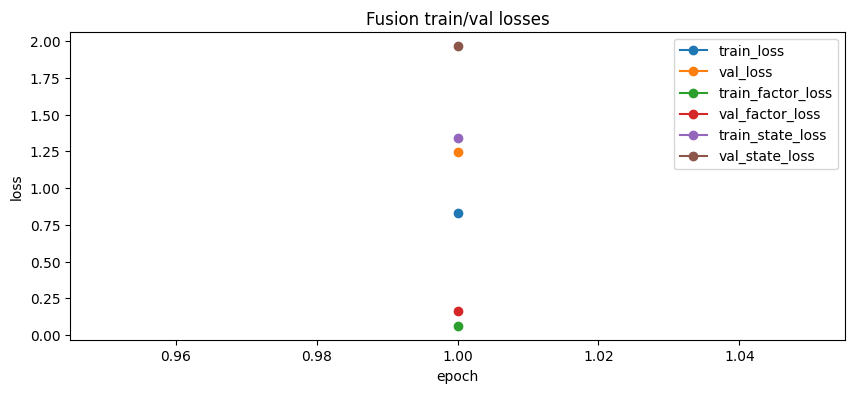

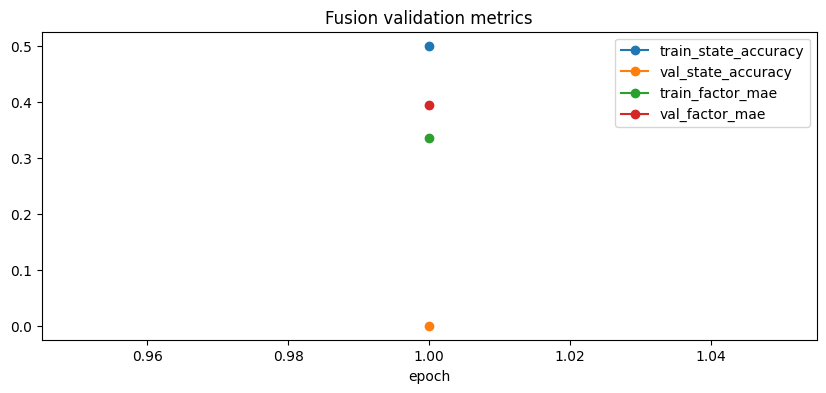

In [11]:
if fusion_history is not None and plt is not None:
    cols = [c for c in ["train_loss", "val_loss", "train_factor_loss", "val_factor_loss", "train_state_loss", "val_state_loss"] if c in fusion_history.columns]
    ax = fusion_history.plot(x="epoch", y=cols, figsize=(10, 4), marker="o", title="Fusion train/val losses")
    ax.set_ylabel("loss")
    plt.show()

    acc_cols = [c for c in ["train_state_accuracy", "val_state_accuracy", "train_factor_mae", "val_factor_mae"] if c in fusion_history.columns]
    if acc_cols:
        ax = fusion_history.plot(x="epoch", y=acc_cols, figsize=(10, 4), marker="o", title="Fusion validation metrics")
        plt.show()
else:
    print("Skip plot: no fusion history or matplotlib unavailable.")

## 7. Switching predictive LOSO validation

LOSO = Leave-One-Subject-Out. Pour chaque fold:

- un user est garde comme test;
- des users restants servent a train;
- une petite partie des users restants sert a validation;
- le checkpoint `best.pt` est choisi par plus petite `val_loss`.

In [12]:
loso_summary = read_csv(SWITCHING_DIR / "loso_summary.csv")
loso_results = read_json(SWITCHING_DIR / "loso_results.json")
train_loso = read_json(SWITCHING_DIR / "train_loso_results.json")

if loso_results:
    overall = {
        "num_folds": loso_results.get("num_folds"),
        "num_samples": loso_results.get("num_samples"),
        "factor_mae": loso_results.get("factor_mae"),
        "factor_rmse": loso_results.get("factor_rmse"),
        "state_accuracy": loso_results.get("state_accuracy"),
        "macro_f1": loso_results.get("macro_f1"),
        "mcc": loso_results.get("mcc"),
        "cohen_kappa": loso_results.get("cohen_kappa"),
    }
    display(show_table([overall]))
else:
    print("No switching loso_results.json found.")

if loso_summary is not None:
    display(loso_summary)
else:
    print("No switching loso_summary.csv found or pandas unavailable.")

,num_folds,num_samples,factor_mae,factor_rmse,state_accuracy,macro_f1,mcc,cohen_kappa
0,10,371,0.199803,0.268549,0.210243,0.069488,-0.299596,-0.182531


,test_user,num_samples,factor_mae,factor_rmse,state_accuracy,macro_f1,mcc,cohen_kappa,checkpoint
0,amrdroid,16,0.177339,0.221536,0.00000,0.000000,0.0,0.0,outputs\switching_predictive\fold_amrdroid\bes...
1,dem,161,0.134559,0.158108,0.21118,0.069744,0.0,0.0,outputs\switching_predictive\fold_dem\best.pt
2,ghoss,15,0.218621,0.274587,0.00000,0.000000,0.0,0.0,outputs\switching_predictive\fold_ghoss\best.pt
3,Graja,11,0.239358,0.278042,0.00000,0.000000,0.0,0.0,outputs\switching_predictive\fold_Graja\best.pt
4,hffz,41,0.300586,0.316238,0.04878,0.018605,0.0,0.0,outputs\switching_predictive\fold_hffz\best.pt
5,ignorant,16,0.059561,0.070276,0.00000,0.000000,0.0,0.0,outputs\switching_predictive\fold_ignorant\bes...
6,ladabos,16,0.218170,0.262594,0.00000,0.000000,0.0,0.0,outputs\switching_predictive\fold_ladabos\best.pt
7,layss,64,0.220657,0.373523,0.40625,0.115556,0.0,0.0,outputs\switching_predictive\fold_layss\best.pt
8,Makki,15,0.362409,0.390873,0.00000,0.000000,0.0,0.0,outputs\switching_predictive\fold_Makki\best.pt
9,mohanned,16,0.461721,0.465105,1.00000,0.200000,0.0,0.0,outputs\switching_predictive\fold_mohanned\bes...


In [13]:
fold_histories = []
if pd is not None:
    for path in sorted(SWITCHING_DIR.glob("fold_*/history.csv")):
        df = pd.read_csv(path)
        df["fold"] = path.parent.name.replace("fold_", "")
        fold_histories.append(df)

if fold_histories:
    switching_history = pd.concat(fold_histories, ignore_index=True)
    best_by_fold = switching_history.loc[switching_history.groupby("fold")["val_loss"].idxmin()].copy()
    best_by_fold = best_by_fold.sort_values("val_loss")
    display(best_by_fold[["fold", "epoch", "train_loss", "val_loss", "train_state_accuracy", "val_state_accuracy"]])
else:
    switching_history = None
    print("No fold histories found or pandas unavailable.")

,fold,epoch,train_loss,val_loss,train_state_accuracy,val_state_accuracy
25,dem,4,0.908910,0.487920,0.386598,1.00000
153,Makki,2,0.912392,0.641011,0.308824,1.00000
76,Graja,22,0.904249,0.675019,0.313043,1.00000
9,amrdroid,10,0.916286,0.765933,0.326471,0.00000
42,ghoss,5,0.918036,0.775922,0.326471,0.00000
96,hffz,8,0.757051,0.904250,0.364662,0.40625
126,ladabos,5,0.910612,0.920777,0.326460,0.25000
166,mohanned,1,0.992857,1.030534,0.278351,0.21118
139,layss,1,0.998281,1.042524,0.445205,0.21118
109,ignorant,1,0.984663,1.150823,0.283439,0.04878


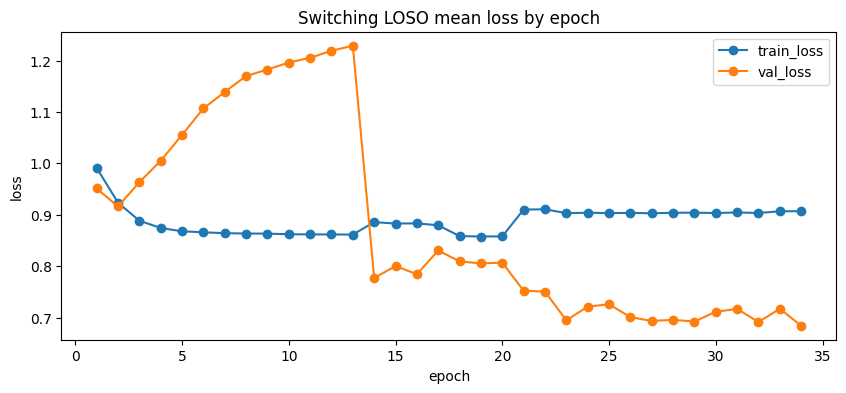

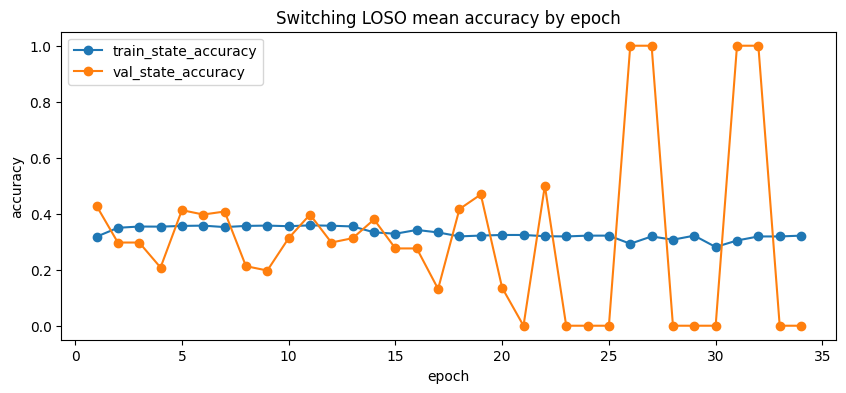

In [14]:
if switching_history is not None and plt is not None:
    mean_by_epoch = switching_history.groupby("epoch")[["train_loss", "val_loss", "train_state_accuracy", "val_state_accuracy"]].mean().reset_index()
    ax = mean_by_epoch.plot(x="epoch", y=["train_loss", "val_loss"], figsize=(10, 4), marker="o", title="Switching LOSO mean loss by epoch")
    ax.set_ylabel("loss")
    plt.show()
    ax = mean_by_epoch.plot(x="epoch", y=["train_state_accuracy", "val_state_accuracy"], figsize=(10, 4), marker="o", title="Switching LOSO mean accuracy by epoch")
    ax.set_ylabel("accuracy")
    plt.show()
else:
    print("Skip switching LOSO plots.")

## 8. Confusion matrix and per-class validation

Cette partie resume les erreurs de classification switching sur les folds LOSO.

In [15]:
STATE_NAMES = ["Flow", "Neutral", "Bored", "Distracted", "Overloaded"]

if loso_results and pd is not None:
    cm = np.asarray(loso_results["confusion_matrix"], dtype=int)
    cm_df = pd.DataFrame(cm, index=[f"true_{s}" for s in STATE_NAMES], columns=[f"pred_{s}" for s in STATE_NAMES])
    display(cm_df)

    per_class = pd.DataFrame({
        "state": STATE_NAMES,
        "f1": loso_results.get("per_class_f1", [None] * 5),
        "true_count": cm.sum(axis=1),
        "pred_count": cm.sum(axis=0),
    })
    display(per_class)
else:
    print("No confusion matrix available.")

,pred_Flow,pred_Neutral,pred_Bored,pred_Distracted,pred_Overloaded
true_Flow,0,39,0,0,0
true_Neutral,0,78,0,47,0
true_Bored,0,65,0,0,0
true_Distracted,0,111,0,0,0
true_Overloaded,0,31,0,0,0


,state,f1,true_count,pred_count
0,Flow,0.000000,39,0
1,Neutral,0.347439,125,324
2,Bored,0.000000,65,0
3,Distracted,0.000000,111,47
4,Overloaded,0.000000,31,0


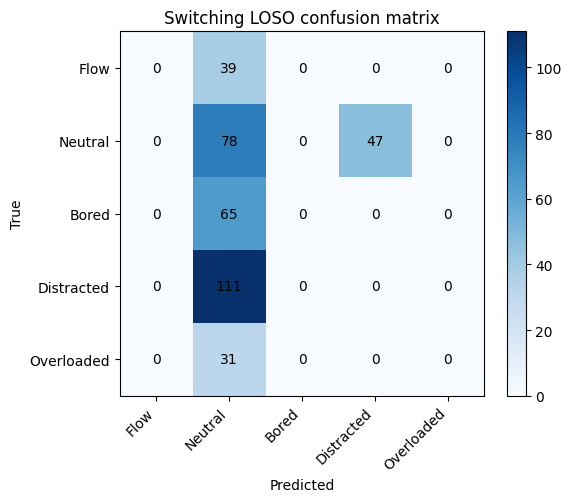

In [16]:
if loso_results and plt is not None:
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_xticklabels(STATE_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(STATE_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Switching LOSO confusion matrix")
    for i in range(5):
        for j in range(5):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
else:
    print("Skip confusion matrix plot.")

## 9. Final switching model checkpoint

Le modele final unique est entraine sur toutes les donnees disponibles. Il sert plutot pour l'integration/deployment-style inference, pas pour estimer la generalisation unbiased.

In [17]:
final_summary = read_json(SWITCHING_DIR / "final" / "final_training_summary.json")
refit_history = read_csv(SWITCHING_DIR / "final" / "refit_history.csv")
validation_history = read_csv(SWITCHING_DIR / "final" / "validation_history.csv")

if final_summary:
    display(show_table([final_summary]))
else:
    print("No final_training_summary.json found.")

if validation_history is not None:
    print("Validation history tail")
    display(validation_history.tail())

if refit_history is not None:
    print("Refit history tail")
    display(refit_history.tail())

,best_epoch_from_validation,checkpoint,data_dir,device,num_samples,num_users,trained_on_all_samples,validation_loss
0,1,outputs\switching_predictive\final\best.pt,data_training,cpu,371,10,True,1.116427


Validation history tail


,epoch,train_loss,train_factor_loss,train_state_loss,train_state_accuracy,train_num_samples,val_loss,val_factor_loss,val_state_loss,val_state_accuracy,val_num_samples
8,9,0.764221,0.027440,1.255408,0.375796,314.0,2.502512,0.060183,4.130732,0.000000,57.0
9,10,0.766789,0.027379,1.259729,0.350318,314.0,2.611096,0.059089,4.312434,0.035088,57.0
10,11,0.765975,0.027938,1.258000,0.391720,314.0,2.681678,0.060171,4.429348,0.035088,57.0
11,12,0.766767,0.027522,1.259597,0.337580,314.0,2.685144,0.059496,4.435576,0.035088,57.0
12,13,0.766442,0.027958,1.258766,0.391720,314.0,2.709019,0.058982,4.475710,0.035088,57.0


Refit history tail


,epoch,loss,factor_loss,state_loss,state_accuracy,num_samples
0,1,0.984127,0.093644,1.577782,0.277628,371.0


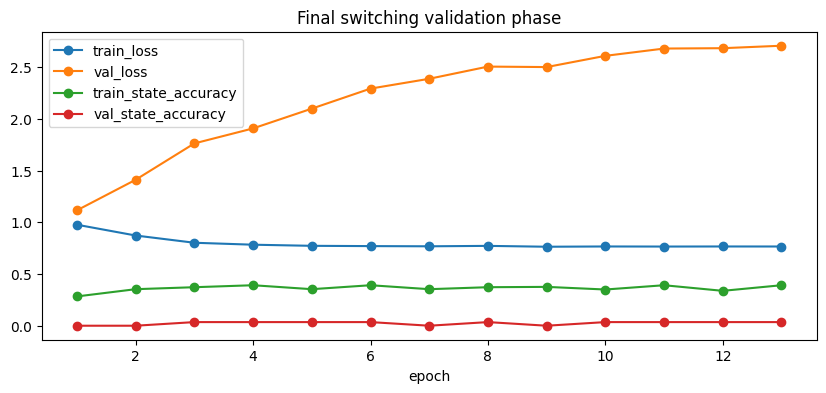

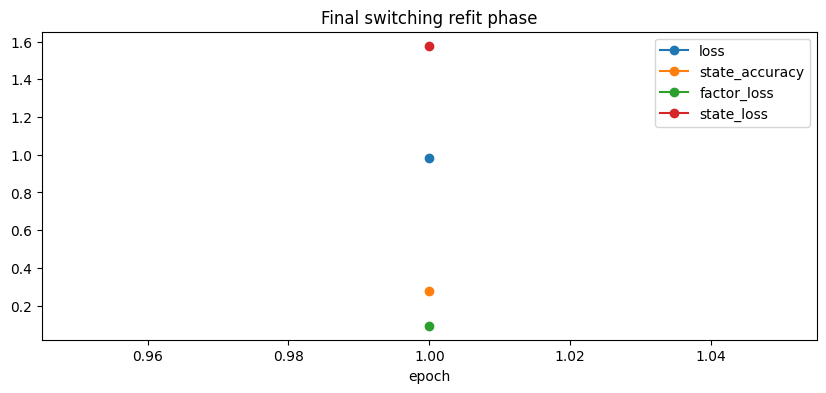

In [18]:
if validation_history is not None and plt is not None:
    cols = [c for c in ["train_loss", "val_loss", "train_state_accuracy", "val_state_accuracy"] if c in validation_history.columns]
    ax = validation_history.plot(x="epoch", y=cols, figsize=(10, 4), marker="o", title="Final switching validation phase")
    plt.show()

if refit_history is not None and plt is not None:
    cols = [c for c in ["loss", "state_accuracy", "factor_loss", "state_loss"] if c in refit_history.columns]
    ax = refit_history.plot(x="epoch", y=cols, figsize=(10, 4), marker="o", title="Final switching refit phase")
    plt.show()

## 10. Optional checkpoint architecture inspection

Cette cellule charge seulement les metadata du checkpoint avec `map_location='cpu'`. Elle ne modifie pas les poids.

In [19]:
if TORCH_AVAILABLE:
    checkpoint_rows = []
    for path in [
        FUSION_SMOKE_TRAIN_DIR / "checkpoints" / "best.pt",
        FUSION_TRAIN_DIR / "checkpoints" / "best.pt",
        SWITCHING_DIR / "final" / "best.pt",
    ]:
        if not path.is_file():
            continue
        try:
            ckpt = torch.load(path, map_location="cpu", weights_only=False)
        except TypeError:
            ckpt = torch.load(path, map_location="cpu")
        checkpoint_rows.append({
            "checkpoint": str(path.relative_to(ROOT)),
            "keys": sorted(list(ckpt.keys())),
            "epoch": ckpt.get("epoch"),
            "val_loss": ckpt.get("val_loss"),
            "input_flat_dim": ckpt.get("input_flat_dim"),
            "d_proj": ckpt.get("d_proj"),
            "hidden_dim": ckpt.get("hidden_dim"),
        })
    show_table(checkpoint_rows)
else:
    print("Skip checkpoint inspection because Torch is unavailable.")

## 11. Quick interpretation checklist

- If train loss decreases but val loss does not: overfitting or too few/generalization-poor labels.
- If state accuracy is low and factor MAE is acceptable: the factor regression may be easier than the derived state labels.
- If class F1 is zero for several states: inspect class imbalance and the state derivation heuristic.
- If `switching` input is `(B, 512)`: this is the Tucker slice given to the predictive GRU.
- If switching embedding before TFN is `(B, 64)`: identity-only GNN integration is active.
- The GNN decoder is not part of this notebook or the fusion inference path.

## 12. Commands to regenerate metrics

Run these from the project root if you need fresh result files:

```powershell
python scripts/fusion/train_fusion.py --data-dir data --epochs 50 --batch-size 8 --device cpu
python scripts/fusion/evaluate_fusion.py --checkpoint outputs/fusion_train/checkpoints/best.pt --data-dir data --split test --device cpu
python scripts/switching/train_switching_predictive.py --data-dir data_training --epochs 100 --batch-size 32 --device cpu
python scripts/switching/evaluate_switching_predictive.py --data-dir data_training --checkpoint-dir outputs/switching_predictive --device cpu
```